**Spam SMS Detection**

Dataset Loading

In [1]:
import zipfile
import os

zip_path = "/content/SMS dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/sms_data")

print("Dataset Extracted Successfully!")

for root, dirs, files in os.walk("/content/sms_data"):
    for file in files:
        print(file)

Dataset Extracted Successfully!
spam.csv


Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

Dataset Preview

In [3]:
df = pd.read_csv(
    "/content/sms_data/spam.csv",
    encoding='latin-1'
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Data Cleaning

In [4]:
df = df[['v1','v2']]

df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Exploratory Data Analysis

In [5]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Missing Values:
label      0
message    0
dtype: int64

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


Data Visualization

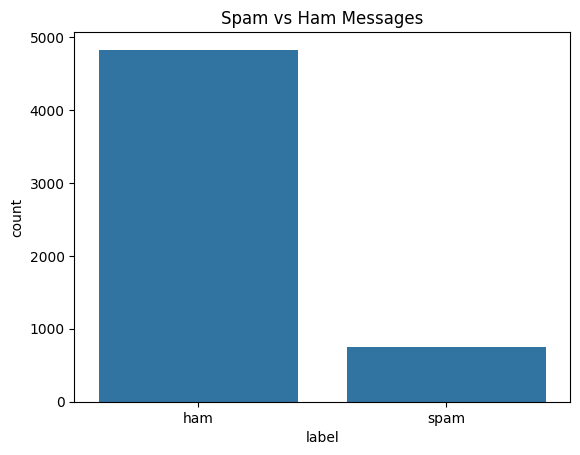

In [6]:
sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Messages")
plt.show()

Label Encoding

In [7]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Train-Test Split

In [8]:
X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4457
Testing Samples: 1115


Text Vectorization using TF-IDF

In [9]:
vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (4457, 7472)
Testing Shape: (1115, 7472)


Naive Bayes Model Training

In [10]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model Training Completed!")

Model Training Completed!


Model Prediction

In [11]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

[0 0 0 0 1 0 0 0 0 0]


Accuracy Metric

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 96.68 %


Classification Report

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



Confusion Matrix

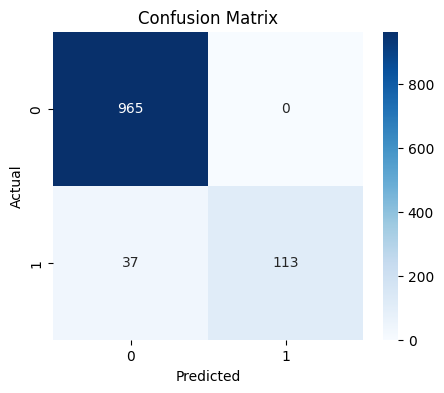

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Real-Time Testing

In [15]:
def predict_sms(text):
    text_vector = vectorizer.transform([text])
    prediction = model.predict(text_vector)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

sample_sms = "Congratulations! You have won a free iPhone. Click here now."

print("Message:", sample_sms)
print("Prediction:", predict_sms(sample_sms))

Message: Congratulations! You have won a free iPhone. Click here now.
Prediction: SPAM
